--- Data Information ---
Training shapes: (120, 4), Testing shapes: (30, 4)

--- 1. Unconstrained Decision Tree ---
Train Accuracy: 1.0000
Test Accuracy:  1.0000



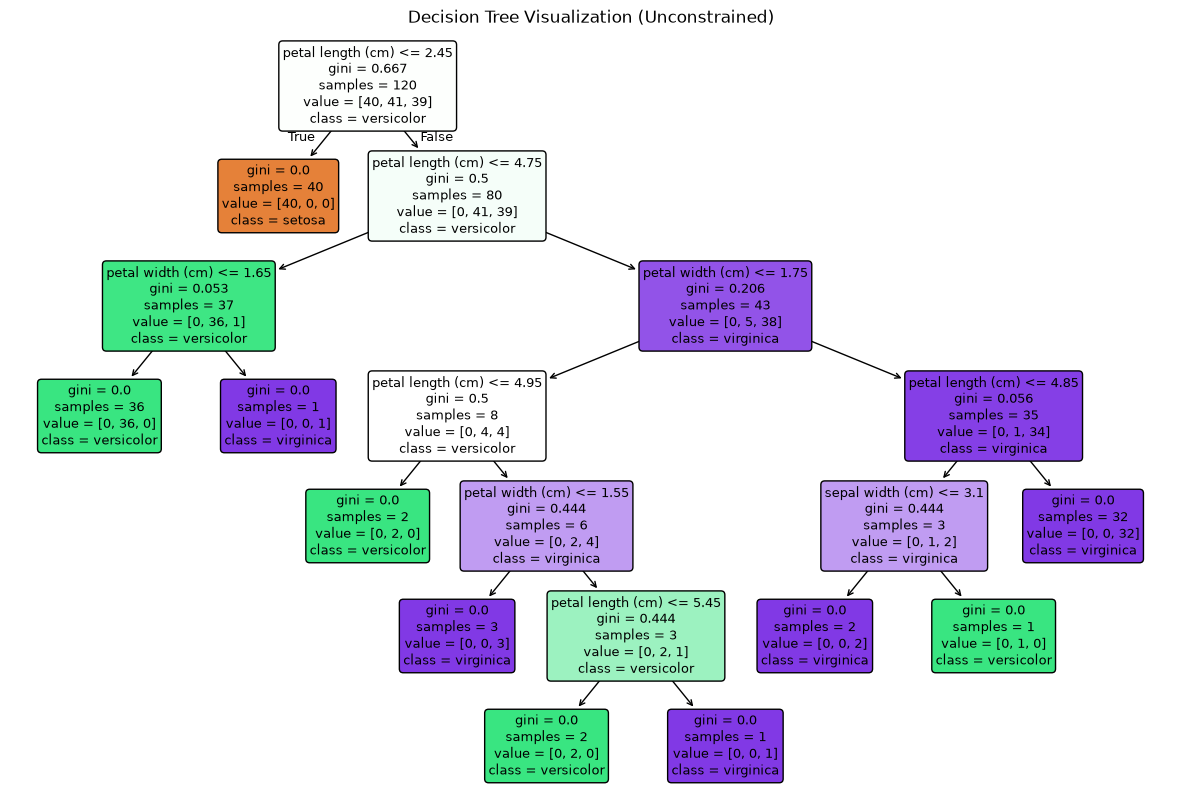

--- 2. Pruned Decision Tree (max_depth=3) ---
Train Accuracy: 0.9583
Test Accuracy:  1.0000



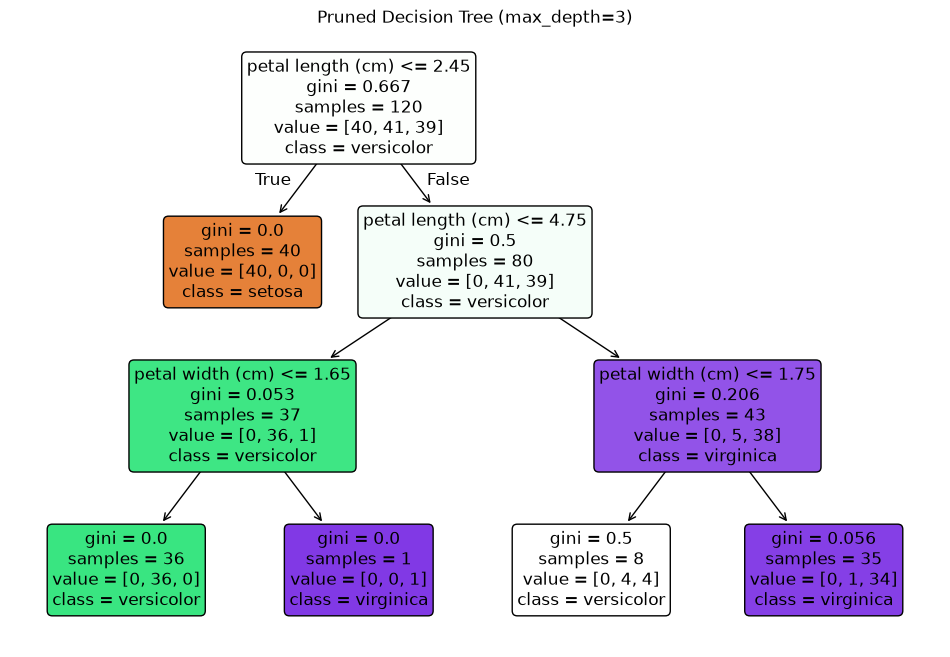

--- 3. Random Forest Comparison ---
Decision Tree (Pruned) Test Accuracy: 1.0000
Random Forest Test Accuracy:         1.0000

Classification Report for Random Forest:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


--- 4. Feature Importances ---
             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


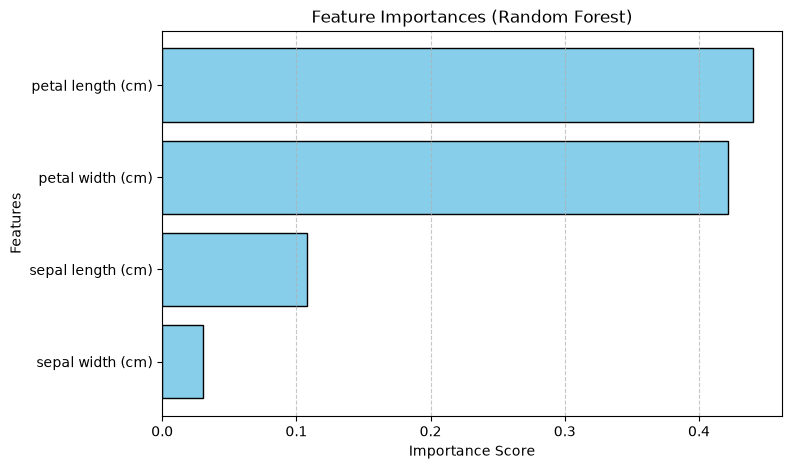


--- 5. 5-Fold Cross-Validation Results ---
Scores for each fold: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV Accuracy:     0.9667
Standard Deviation:   0.0211


In [3]:
# ==============================================================================
# TASK 5: DECISION TREES & RANDOM FORESTS (FINAL)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------------------------------------------
# 1. DATA LOADING & SPLITTING
# ------------------------------------------------------------------------------
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Split data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Data Information ---")
print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}\n")

# ------------------------------------------------------------------------------
# 2. DECISION TREE (UNCONSTRAINED) & VISUALIZATION (Hint 1)
# ------------------------------------------------------------------------------
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt_classifier.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_classifier.predict(X_test))

print("--- 1. Unconstrained Decision Tree ---")
print(f"Train Accuracy: {dt_train_acc:.4f}")
print(f"Test Accuracy:  {dt_test_acc:.4f}\n")

plt.figure(figsize=(15, 10))
plot_tree(dt_classifier, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Visualization (Unconstrained)")
plt.show()

# ------------------------------------------------------------------------------
# 3. CONTROLLING OVERFITTING (Hint 2)
# ------------------------------------------------------------------------------
pruned_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_dt.fit(X_train, y_train)

pruned_train_acc = accuracy_score(y_train, pruned_dt.predict(X_train))
pruned_test_acc = accuracy_score(y_test, pruned_dt.predict(X_test))

print("--- 2. Pruned Decision Tree (max_depth=3) ---")
print(f"Train Accuracy: {pruned_train_acc:.4f}")
print(f"Test Accuracy:  {pruned_test_acc:.4f}\n")

plt.figure(figsize=(12, 8))
plot_tree(pruned_dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.show()

# ------------------------------------------------------------------------------
# 4. RANDOM FOREST & ACCURACY COMPARISON (Hint 3)
# ------------------------------------------------------------------------------
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_classifier.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_classifier.predict(X_test))

print("--- 3. Random Forest Comparison ---")
print(f"Decision Tree (Pruned) Test Accuracy: {pruned_test_acc:.4f}")
print(f"Random Forest Test Accuracy:         {rf_test_acc:.4f}\n")

print("Classification Report for Random Forest:")
print(classification_report(y_test, rf_classifier.predict(X_test), target_names=iris.target_names))

# ------------------------------------------------------------------------------
# 5. FEATURE IMPORTANCES (Hint 4)
# ------------------------------------------------------------------------------
importances = rf_classifier.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- 4. Feature Importances ---")
print(feature_imp_df)

plt.figure(figsize=(8, 5))
plt.barh(feature_imp_df['Feature'][::-1], feature_imp_df['Importance'][::-1], color='skyblue', edgecolor='k')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importances (Random Forest)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# ------------------------------------------------------------------------------
# 6. CROSS-VALIDATION (Hint 5)
# ------------------------------------------------------------------------------
cv_scores = cross_val_score(rf_classifier, X, y, cv=5)

print("\n--- 5. 5-Fold Cross-Validation Results ---")
print(f"Scores for each fold: {cv_scores}")
print(f"Mean CV Accuracy:     {cv_scores.mean():.4f}")
print(f"Standard Deviation:   {cv_scores.std():.4f}")


